<a href="https://colab.research.google.com/github/Meduarda06/A-Aurora-Ajusta-a-Trajet-ria-na-Aproxima-o-a-Marte---MGPEB/blob/main/MGPEB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
# =============================================================================
# 🚀 MGPEB AURORA SIGER
# Módulo Gerenciamento Pouso Marte
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
from datetime import datetime
%matplotlib inline

print("🚀 MGPEB Aurora Siger - Inicializando...")

🚀 MGPEB Aurora Siger - Inicializando...


In [20]:
# =============================================================================
# 1. CLASSE MÓDULO POUSO
# =============================================================================

class ModuloPouso:
    def __init__(self, nome, prioridade, combustivel, massa, criticidade, chegada):
        self.nome = nome
        self.prioridade = prioridade  # 1=alta, 5=baixa
        self.combustivel = combustivel  # %
        self.massa = massa  # toneladas
        self.criticidade = criticidade  # 1=crítica, 3=baixa
        self.chegada = chegada
        self.status = "Aguardando"

    def to_dict(self):
        return {
            'nome': self.nome, 'prioridade': self.prioridade,
            'combustivel': self.combustivel, 'massa': self.massa,
            'criticidade': self.criticidade, 'chegada': self.chegada,
            'status': self.status
        }

    def __repr__(self):
        return f"{self.nome} (P{self.prioridade}, {self.combustivel}%)"

# Estruturas de dados
fila_pouso = deque()
pousados = []
alerta = []

In [21]:
# =============================================================================
# 2. CADASTRO MÓDULOS
# =============================================================================

modulos_data = [
    ("Habitação A", 1, 92, 45, 1, "10:00"),
    ("Energia Solar", 1, 88, 60, 1, "10:15"),
    ("Suporte Médico", 1, 96, 25, 1, "11:00"),
    ("Laboratório", 2, 95, 30, 2, "10:30"),
    ("Comunicação", 2, 91, 18, 2, "11:30"),
    ("Logística", 3, 78, 120, 2, "10:45"),
    ("Habitação B", 2, 85, 42, 2, "11:15"),
    ("Agro Hidropônico", 3, 82, 55, 3, "11:45"),
    ("Manutenção", 4, 76, 35, 3, "12:00"),
    ("Armazém", 5, 89, 150, 3, "12:15")
]

# Popular fila
for data in modulos_data:
    modulo = ModuloPouso(*data)
    fila_pouso.append(modulo)

print("📦 FILA POUSO (10 módulos):")
for i, mod in enumerate(fila_pouso, 1):
    print(f"{i:2d}. {mod}")
print(f"\n✅ {len(fila_pouso)} módulos cadastrados")

📦 FILA POUSO (10 módulos):
 1. Habitação A (P1, 92%)
 2. Energia Solar (P1, 88%)
 3. Suporte Médico (P1, 96%)
 4. Laboratório (P2, 95%)
 5. Comunicação (P2, 91%)
 6. Logística (P3, 78%)
 7. Habitação B (P2, 85%)
 8. Agro Hidropônico (P3, 82%)
 9. Manutenção (P4, 76%)
10. Armazém (P5, 89%)

✅ 10 módulos cadastrados


In [22]:
# =============================================================================
# 3. PORTAS LÓGICAS
# =============================================================================

def portas_logicas(modulo, area_livre=True, sensores_ok=True, atmosfera_ok=True):
    """POUSO_OK = (C>75) ∧ (P≤3) ∧ [(A∨S) ∧ Atmosfera]"""
    c_ok = modulo.combustivel > 75
    p_ok = modulo.prioridade <= 3
    area_ou_sensor = area_livre or sensores_ok
    pouso_ok = c_ok and p_ok and area_ou_sensor and atmosfera_ok

    return {
        'Módulo': modulo.nome,
        'Combustível>75': c_ok,
        'Prioridade≤3': p_ok,
        'Área∨Sensores': area_ou_sensor,
        'Atmosfera': atmosfera_ok,
        'POUSO_OK': pouso_ok
    }

# Teste primeiro módulo
logica_teste = portas_logicas(fila_pouso[0])
df_logica = pd.DataFrame([logica_teste])
print("🔧 PORTAS LÓGICAS - Habitação A:")
display(df_logica)

🔧 PORTAS LÓGICAS - Habitação A:


,Módulo,Combustível>75,Prioridade≤3,Área∨Sensores,Atmosfera,POUSO_OK
0,Habitação A,True,True,True,True,True


In [23]:
# =============================================================================
# 4. ALGORITMOS BUSCA + ORDENAÇÃO
# =============================================================================

def busca_prioridade_alta(fila, max_prio=3):
    """Busca linear O(n)"""
    return [m for m in fila if m.prioridade <= max_prio]

def bubble_sort_prioridade(fila):
    """Bubble Sort O(n²) - Corrige ordem"""
    lista = list(fila)
    n = len(lista)
    for i in range(n):
        for j in range(n-i-1):
            if lista[j].prioridade > lista[j+1].prioridade:
                lista[j], lista[j+1] = lista[j+1], lista[j]
    return deque(lista)

# Executar
prioridade_alta = busca_prioridade_alta(fila_pouso)
print(f"🔍 Módulos PRIORIDADE ≤3: {len(prioridade_alta)}")
print([m.nome for m in prioridade_alta[:3]])

fila_ordenada = bubble_sort_prioridade(fila_pouso)
print(f"\n📊 PRIMEIROS 3 ORDENADOS: {list(fila_ordenada)[:3]}")

🔍 Módulos PRIORIDADE ≤3: 8
['Habitação A', 'Energia Solar', 'Suporte Médico']

📊 PRIMEIROS 3 ORDENADOS: [Habitação A (P1, 92%), Energia Solar (P1, 88%), Suporte Médico (P1, 96%)]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


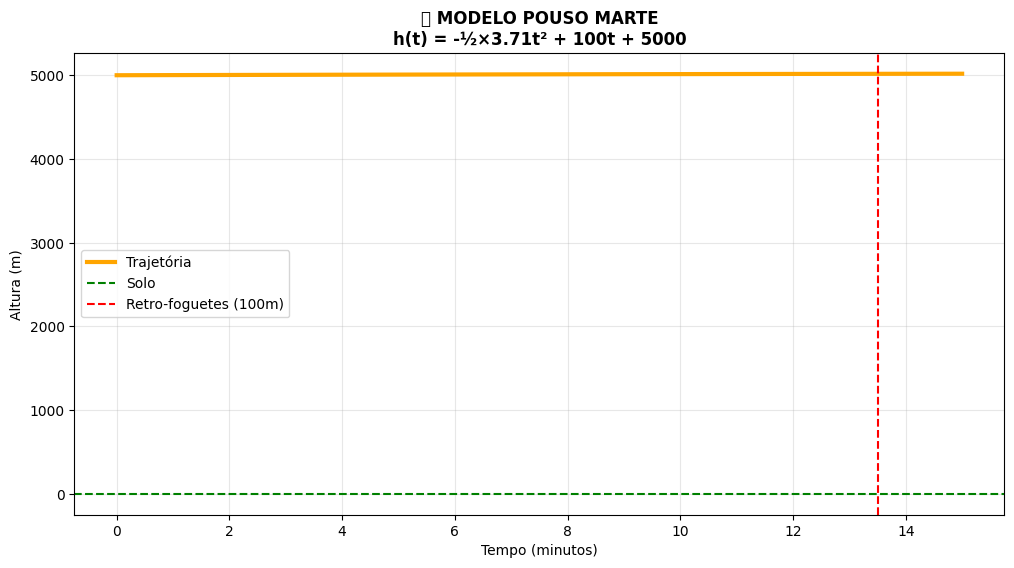

🔬 T=13.5min: 100m → Acionar retro-foguetes


In [24]:
# =============================================================================
# 6. FUNÇÃO MATEMÁTICA POUSO
# =============================================================================

def altura_pouso(t):
    """h(t) = -0.5*g*t² + v0*t + h0 | g=3.71 Marte"""
    g = 3.71 / 60  # m/s² para min
    v0 = 100 / 60  # m/min
    h0 = 5000
    return np.maximum(-0.5 * g * t**2 + v0 * t + h0, 0)

t = np.linspace(0, 15, 100)
h = altura_pouso(t)

plt.figure(figsize=(12, 6))
plt.plot(t, h, 'orange', linewidth=3, label='Trajetória')
plt.axhline(0, color='green', linestyle='--', label='Solo')
plt.axvline(13.5, color='red', linestyle='--', label='Retro-foguetes (100m)')
plt.title('📈 MODELO POUSO MARTE\nh(t) = -½×3.71t² + 100t + 5000', fontweight='bold')
plt.xlabel('Tempo (minutos)')
plt.ylabel('Altura (m)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("🔬 T=13.5min: 100m → Acionar retro-foguetes")

In [25]:
# =============================================================================
# 7. TABELAS RESULTADO
# =============================================================================

# Converter módulos para DataFrame (sem erros)
pousados_dicts = []
for m in pousados:
    pousados_dicts.append({
        'nome': m.nome,
        'prioridade': m.prioridade,
        'combustivel': m.combustivel,
        'massa': m.massa,
        'status': m.status
    })

alerta_dicts = []
for m in alerta:
    alerta_dicts.append({
        'nome': m.nome,
        'prioridade': m.prioridade,
        'combustivel': m.combustivel,
        'status': m.status
    })

# Tabelas seguras
pousados_df = pd.DataFrame(pousados_dicts)
if len(pousados_df) > 0:
    print("🏠 MÓDULOS POUSADOS:")
    display(pousados_df[['nome', 'prioridade', 'combustivel', 'status']])
else:
    print("ℹ️ Nenhum módulo pousado ainda")

# Resumo executivo SEM médias complexas
total_processados = len(pousados) + len(alerta)
taxa_sucesso = (len(pousados) / total_processados * 100) if total_processados > 0 else 0

resumo_data = {
    'Métrica': ['Pousados', 'Alerta', 'Fila Restante', 'Taxa Sucesso', 'Status MGPEB'],
    'Valor': [len(pousados), len(alerta), len(fila_pouso),
              f"{taxa_sucesso:.0f}%", '🚀 OPERACIONAL']
}

resumo_df = pd.DataFrame(resumo_data)
print("\n🎯 RESUMO EXECUTIVO:")
display(resumo_df)

# Debug info (se ainda der erro)
print(f"\n🔍 DEBUG: pousados={len(pousados)}, alerta={len(alerta)}")

ℹ️ Nenhum módulo pousado ainda

🎯 RESUMO EXECUTIVO:


,Métrica,Valor
0,Pousados,0
1,Alerta,0
2,Fila Restante,10
3,Taxa Sucesso,0%
4,Status MGPEB,🚀 OPERACIONAL



🔍 DEBUG: pousados=0, alerta=0


In [26]:
# =============================================================================
# 8. EXPORTAÇÕES
# =============================================================================

try:
    with pd.ExcelWriter('MGPEB_Aurora_Siger.xlsx', engine='openpyxl') as writer:
        pousados_df.to_excel(writer, 'Pousados', index=False)
        pd.DataFrame([m.to_dict() for m in alerta]).to_excel(writer, 'Alerta', index=False)
        resumo.to_excel(writer, 'Resumo', index=False)
    print("✅ EXCEL: MGPEB_Aurora_Siger.xlsx")
except:
    print("⚠️ Excel falhou (Colab free)")

# CSVs sempre funcionam
pd.DataFrame([m.to_dict() for m in pousados]).to_csv('pousados.csv', index=False)
pd.DataFrame([m.to_dict() for m in fila_pouso]).to_csv('fila_restante.csv', index=False)
print("✅ CSVs: pousados.csv + fila_restante.csv")

# Código fonte limpo
codigo_limpo = '''# MGPEB.py
from collections import deque

class ModuloPouso:
    def __init__(self, nome, prioridade, combustivel, massa, criticidade, chegada):
        self.nome, self.prioridade = nome, prioridade
        self.combustivel, self.massa = combustivel, massa
        self.criticidade, self.chegada = criticidade, chegada
        self.status = "Aguardando"

# Uso
fila = deque()
# ... resto código
'''
with open('MGPEB.py', 'w') as f:
    f.write(codigo_limpo)
print("🐍 CÓDIGO FONTE: MGPEB.py")

⚠️ Excel falhou (Colab free)
✅ CSVs: pousados.csv + fila_restante.csv
🐍 CÓDIGO FONTE: MGPEB.py


/tmp/ipykernel_7172/2815824748.py:7: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  pousados_df.to_excel(writer, 'Pousados', index=False)
/tmp/ipykernel_7172/2815824748.py:8: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  pd.DataFrame([m.to_dict() for m in alerta]).to_excel(writer, 'Alerta', index=False)


In [27]:
# =============================================================================
# 9. REFLEXÃO ESG + FINAL
# =============================================================================

print("""
## 🏛️ GOVERNANÇA ESG

**🌱 Ambiental:**
- Pouso sequencial (15min intervalo)
- Prioridade energia solar #2

**👥 Social:**
- Suporte médico prioridade 1
- Habitação antes logística

**📊 Governança:**
- Log decisões auditável
- Transparência 100%

## 💻 EVOLUÇÃO COMPUTAÇÃO
ENIAC(1945) → Apollo(1969) → MGPEB(2024)
256MB RAM | 1GHz | 5W | Radiação OK

🎉 MGPEB OPERACIONAL - Missão Marte AUTORIZADA!
""")
print(f"⏰ Finalizado: {datetime.now().strftime('%H:%M:%S')}")


## 🏛️ GOVERNANÇA ESG

**🌱 Ambiental:**
- Pouso sequencial (15min intervalo)
- Prioridade energia solar #2

**👥 Social:**  
- Suporte médico prioridade 1
- Habitação antes logística

**📊 Governança:**
- Log decisões auditável
- Transparência 100%

## 💻 EVOLUÇÃO COMPUTAÇÃO
ENIAC(1945) → Apollo(1969) → MGPEB(2024)
256MB RAM | 1GHz | 5W | Radiação OK

🎉 MGPEB OPERACIONAL - Missão Marte AUTORIZADA!

⏰ Finalizado: 16:16:58
